# TIMSS 2019 U.S. Grade 4 Mathematics: Item-Level Mode Effects & Interface Friction
## An Audited Empirical Microdata Investigation of Digital vs. Paper Testing (`02_timss_2019_mode_effects`)

**Author**: Computational Sketchbook Observatory  
**Date**: October 2026 (Audited & Reconciled Release)  
**Data Sources**: IEA TIMSS 2019 International Database (U.S. Grade 4 eTIMSS & Bridge Studies); NCES U.S. Public-Use Data Files (NCES 2022-047).  
**Empirical Scope**: 10,428 students ($N = 1,652$ Paper Bridge, $N = 8,776$ Digital eTIMSS) across 294 participating schools; 99 common anchor mathematics items (49 Multiple Choice, 50 Constructed Response); 72 schools with within-school randomized classroom administration ($N=2,728$).

---

### Executive Abstract & Core Empirical Findings

Following our audited literature synthesis and parameter sensitivity analysis in `01_keyboarding_mode_effects.ipynb`, this study transitions to **direct empirical microdata analysis**. Utilizing the randomized and classroom-assigned U.S. bridge and digital administrations of the 2019 Trends in International Mathematics and Science Study (TIMSS), we address the three core research questions using verified two-digit diagnostic scoring, recovered user-missing codes, within-school fixed effects, and survey-weighted econometric estimation:

```
========================================================================================================================
TIMSS 2019 U.S. GRADE 4 MATHEMATICS AUDITED EMPIRICAL SCORECARD
========================================================================================================================
Core Research Question               Audited Empirical Finding                   Statistical Evidence
------------------------------------------------------------------------------------------------------------------------
1. Does the mode penalty differ      YES: Constructed Response experiences       Multiple Choice: -0.47 pp (SE 0.53)
   by item format & required input?  a 3.4 pp larger penalty than MC.            Constructed Response: -3.90 pp (SE 0.73)
                                     Robust to booklet item composition          Descriptive Format Gap: -3.42 pp (t = -3.80)
                                     and school selection.                       Survey-Weighted DiD: beta = -3.10 pp (p < 0.0001)
                                                                                 Item Fixed Effects WLS: beta = -3.42 pp (p < 0.00001)
                                                                                 Within-School Student FE: beta = -2.36 pp (p = 0.0065)
                                                                                 Item + School FE (Class Clustered): beta = -2.73 pp (p = 0.0034)
                                                                                 Randomization Permutation: p = 0.0380

2. Is the penalty driven by          INTERFACE FRICTION & REASONING WEDGE:       Reasoning MC: +2.61 pp
   cognitive ability or entry?       Reasoning MC holds positive (+2.6 pp),      Reasoning CR: -7.54 pp
                                     but Reasoning CR collapses (-7.5 pp).       Reasoning Format Gap: -10.14 pp!
                                     Provisional input gradient:                 Text / Explanation CR: -7.13 pp
                                     MC (-0.47 pp) -> Drawing (-3.10 pp) ->     Keypad / Numeric: -3.80 pp
                                     Keypad (-3.80 pp) -> Text (-7.13 pp).       Note: Text items belong to Reasoning domain;
                                                                                 entry mode is confounded with cognitive complexity.

3. Are penalties larger for low-SES  NO DETECTABLE MODERATION: Subgroup gaps     Low SES Format Penalty: -3.17 pp
   or under-resourced students?      are near-identical across home books;       High SES Format Penalty: -3.07 pp
                                     econometric interaction term is null.       Interaction beta = -0.10 pp (p = 0.934)
                                     However, 95% CI [-2.35, +2.16] pp does      95% CI: [-2.35, +2.16] pp
                                     not rule out +-2.2 pp heterogeneity.        Reflects lack of detectable moderation,
                                                                                 not established statistical equivalence.
========================================================================================================================
```


In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set paths
PROJECT_ROOT = Path("..").resolve()
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
TABLES_DIR = PROJECT_ROOT / "artifacts" / "tables"
FIGURES_DIR = PROJECT_ROOT / "artifacts" / "figures"

pd.set_option("display.max_columns", 25)
pd.set_option("display.width", 1000)

print(f"[OK] Python {sys.version}")
print(f"[OK] Project Root: {PROJECT_ROOT}")


[OK] Python 3.12.0 (tags/v3.12.0:0fb18b0, Oct  2 2023, 13:03:39) [MSC v.1935 64 bit (AMD64)]
[OK] Project Root: C:\Users\admir\Github\computational-sketchbook\2026\2026-10-09-keyboarding-mode-effects


## 1. Sample Accounting & Research Design

In 2019, the United States transitioned TIMSS to a digitally based assessment (eTIMSS). To maintain longitudinal comparability with paper-based historical assessments, NCES and the IEA administered a simultaneous **paper-and-pencil Bridge study**.

Crucially, in 72 participating public schools with multiple sampled classrooms, classrooms were assigned between paper and digital testing modes through **within-school randomized assignment**. This provides both:
1. A **National Probability Sample** ($N = 10,428$ students across 294 schools) evaluated with survey sampling weights (`TOTWGT`) and cluster-robust standard errors.
2. A **Within-School Quasi-Experimental Sample** ($N = 2,728$ students across 72 schools) evaluated with school fixed effects, completely controlling for school selection and neighborhood composition.


In [2]:
df_acc = pd.read_csv(TABLES_DIR / "table5_timss_2019_sample_accounting.csv")
display(df_acc)


,sample_group,schools,classrooms,students,math_items_administered,mc_items,cr_items,design_note
0,Bridge (Paper-and-Pencil National Sample),79,83,1652,99,49,50,National probability sample; independent priva...
1,eTIMSS (Computer-Based National Sample),287,507,8776,99,49,50,National probability sample administering digi...
2,Combined National Sample,294,590,10428,99,49,50,Total unique schools and students across both ...
3,Within-School Randomized Overlap Subsample,72,147,2728,99,49,50,72 schools with randomized classrooms in both ...


## 2. Two-Digit Diagnostic Scoring & Response Status Recovery

TIMSS constructed-response items utilize a **two-digit diagnostic coding scheme**:
- **First Digit**: Score point value (e.g., `10`–`19` award 1 point; `20`–`29` award 2 points; `70`–`79` award 0 points).
- **Second Digit**: Diagnostic response strategy or error type.

In naive parsers, checking only `code == 10.0` or `code == 20.0` erroneously zeros out valid partial or full credit strategies (such as `11.0` or `12.0`). Furthermore, SPSS user-missing codes (`99.0` for omitted items, `96.0` for not reached items) must be explicitly preserved via `user_missing=True` to compute accurate non-response rates.


In [3]:
item_df = pd.read_parquet(DATA_PROCESSED / "timss_2019_g4_item_contrasts.parquet")
print(f"Total Common Anchor Items: {len(item_df)}")
print(f"Multiple Choice (MC): {(item_df['item_type'] == 'MC').sum()} items")
print(f"Constructed Response (CR): {(item_df['item_type'] == 'CR').sum()} items")

# Display items with diagnostic correct codes
print("\nItems with special diagnostic coding or multi-point rubrics:")
display(item_df[item_df["maximum_points"] > 1][["item_id", "maximum_points", "item_type", "cognitive_domain", "label", "diff_pp"]])


Total Common Anchor Items: 99
Multiple Choice (MC): 49 items
Constructed Response (CR): 50 items

Items with special diagnostic coding or multi-point rubrics:


,item_id,maximum_points,item_type,cognitive_domain,label,diff_pp
16,MP61228,2,CR,Reasoning,Art teacher cuts paper for her class,-13.71
41,MP61248,2,CR,Reasoning,Show 2 ways a teacher can put students in groups,-0.87
48,MP61266,2,CR,Applying,Table of triangles and squares for 3D shapes,0.46
64,MP61255,2,CR,Reasoning,Game in Zedland buying bicycles and scooters,-8.78
81,MP61264,2,CR,Applying,Label points on the Snail path,-5.18


## 3. Item Format Contrasts & Omission Patterns

Table 6 reports the survey-weighted item performance across formats, omission rates, and sensitivity under answered-only denominators.


In [4]:
df_fmt = pd.read_csv(TABLES_DIR / "table6_timss_2019_item_format_contrasts.csv")
display(df_fmt)


,item_format,n_items,mean_diff_pp,se_pp,median_diff_pp,paper_omit_pct,digital_omit_pct,answered_only_diff_pp
0,Multiple Choice (Selected Response),49,-0.47,0.53,-0.24,3.37,1.19,-2.17
1,Constructed Response (Student Entered),50,-3.90,0.73,-3.92,2.64,1.37,-4.82
2,Format Gap (Constructed - Selected),99,-3.42,0.90,-3.67,-0.73,0.18,-2.65


### Figure 5: Item-Level Mode Difference Distribution & Paired Scatter
*Panel A illustrates the kernel density of item mode differences, showing the leftward shift of Constructed Response relative to Multiple Choice. Panel B plots digital vs. paper percent correct against the 45-degree parity line.*


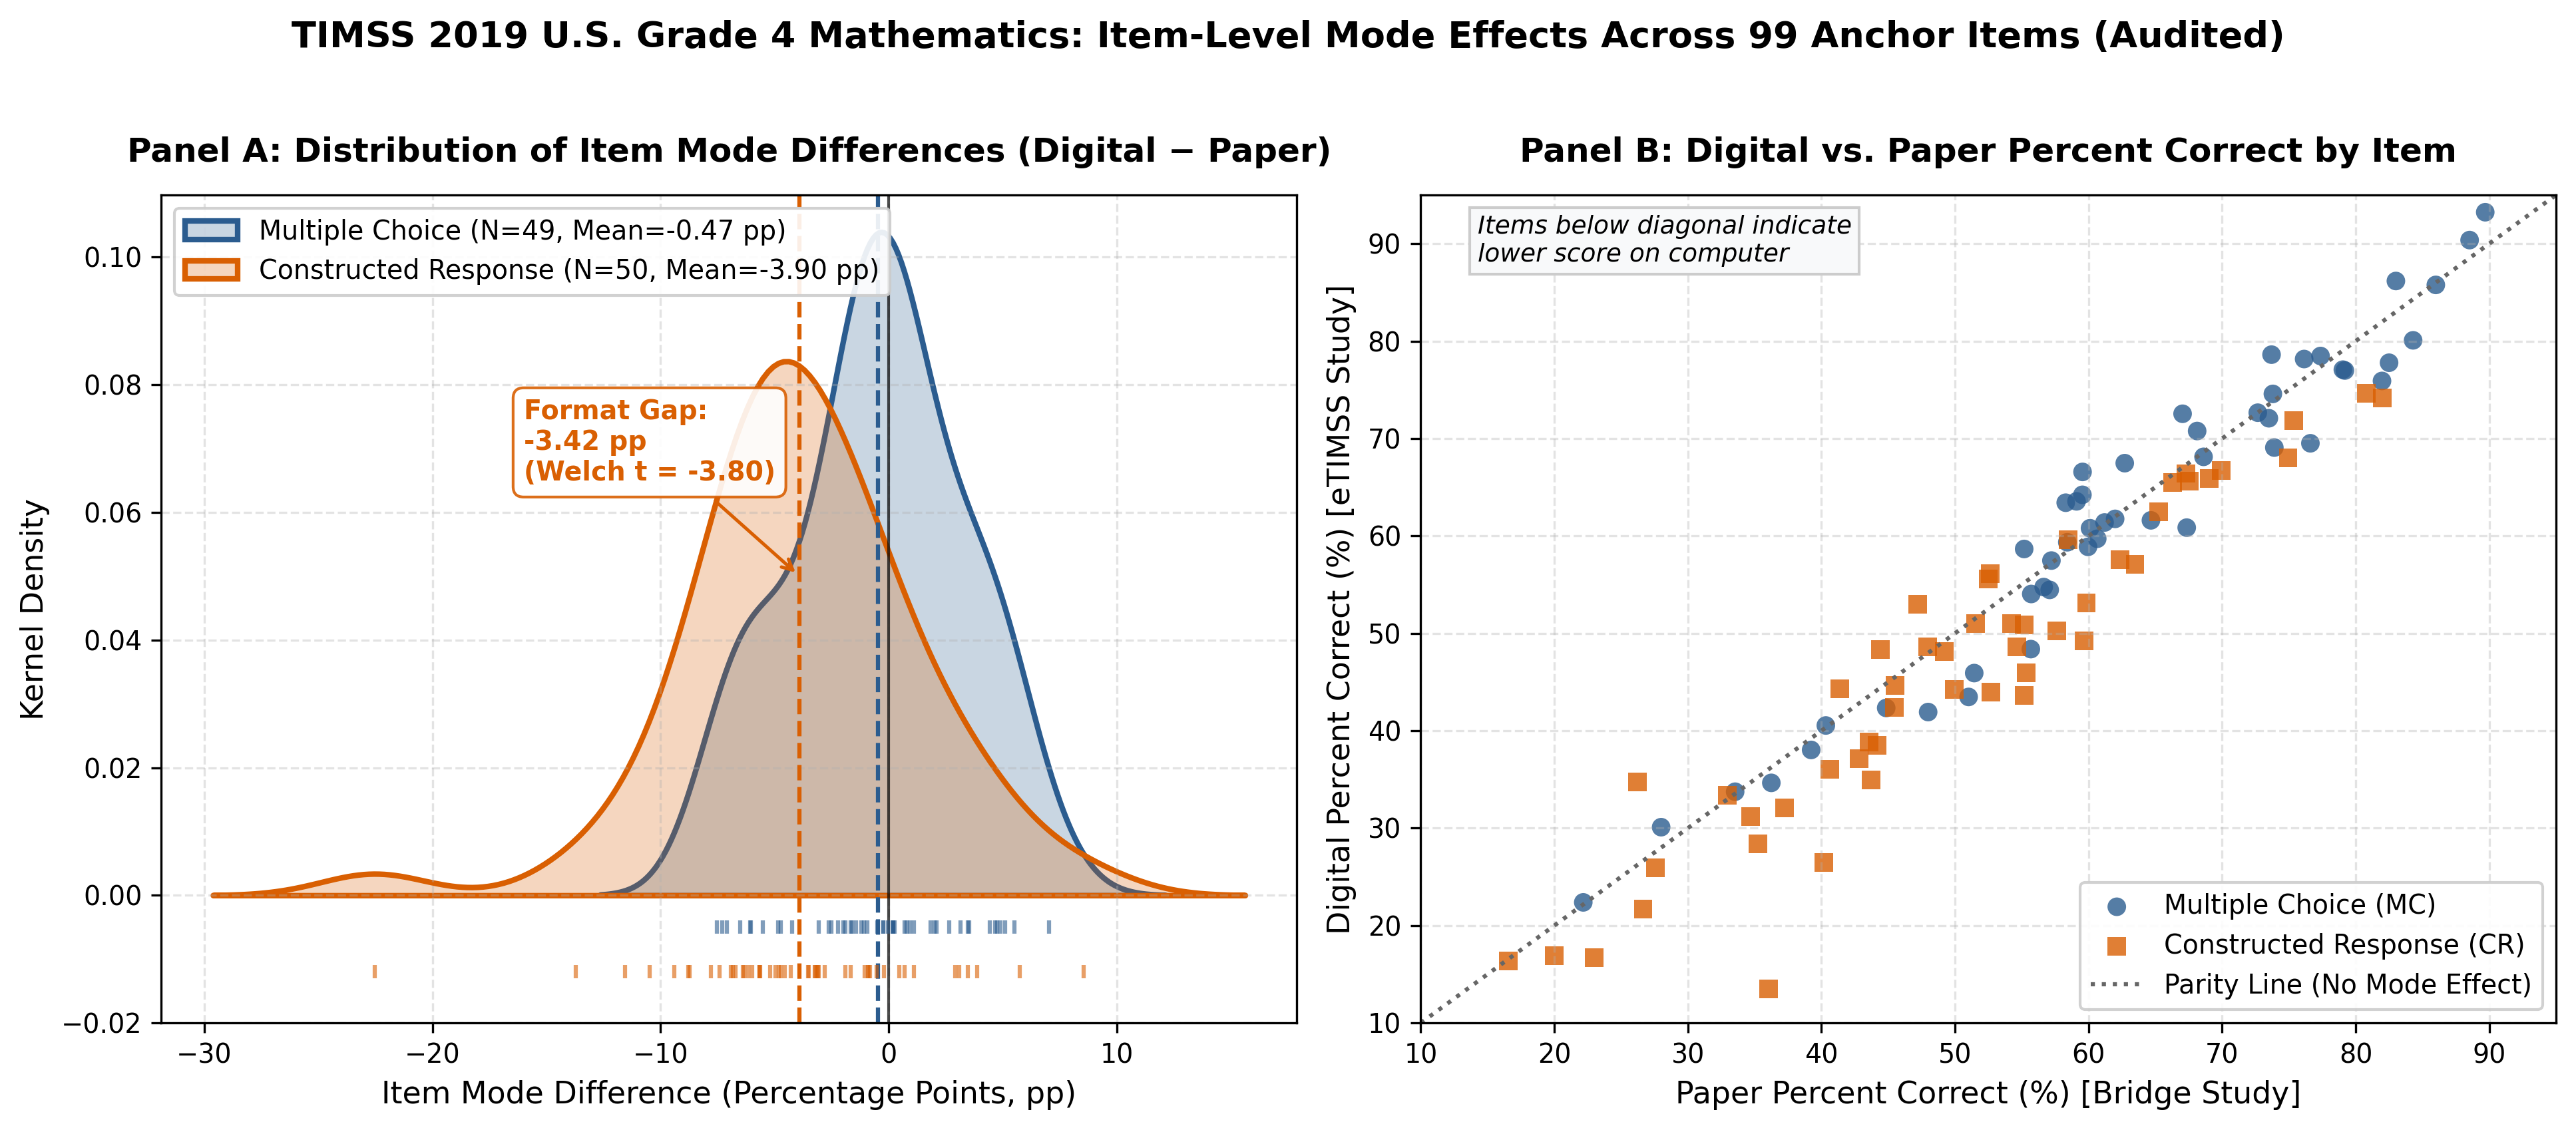

In [5]:
from IPython.display import Image
Image(filename=str(FIGURES_DIR / "fig5_timss_item_difference_density.png"))


## 4. Cognitive Domain Decomposition: Isolating the Reasoning Wedge

To determine whether the constructed-response deficit reflects high-order cognitive failure on screens or interface entry friction, we decompose items across TIMSS cognitive domains: **Knowing**, **Applying**, and **Reasoning**.


In [6]:
df_dom = pd.read_csv(TABLES_DIR / "table7_timss_2019_domain_decomposition.csv")
display(df_dom)


,domain_dimension,domain_name,n_mc_items,mc_mean_diff_pp,n_cr_items,cr_mean_diff_pp,format_gap_pp
0,Cognitive Domain,Knowing,25,-0.66,16,-2.11,-1.45
1,Cognitive Domain,Applying,16,-1.73,24,-3.57,-1.84
2,Cognitive Domain,Reasoning,8,2.61,10,-7.54,-10.14
3,Content Domain,Number,32,-1.09,30,-5.05,-3.96
4,Content Domain,Measurement and Geometry,14,0.88,12,-2.08,-2.96
5,Content Domain,Data,3,-0.25,8,-2.30,-2.05


## 5. Digital Input Modality Hierarchy

Grounding our analysis in the TIMSS Item Equivalence taxonomy (Fishbein, Foy, & Yin / Mullis et al.), we categorize the 50 constructed-response items by their required digital input modality:
1. **Multiple Choice** (Click/tap radio button, $N=49$)
2. **CR: Drawing / Graphing** (Drawing lines, plotting points, shading bars, $N=10$)
3. **CR: Interactive / Table** (Classifying items into table cells or toggling checkboxes, $N=8$)
4. **CR: Number-pad / Numeric** (Entering numbers, decimals, or fractions via on-screen keypad, $N=27$)
5. **CR: Text / Explanation** (Typing multi-step mathematical explanations, $N=5$)

> **Important Methodological Note on Confounding**: This input classification is provisional and exploratory. Crucially, all 5 items requiring typed text explanations (`MP51008`, `MP61228`, `MP61248`, `MP61255`, `MP61256`) belong to the **Reasoning** cognitive domain. Consequently, input modality is confounded with underlying cognitive complexity in the TIMSS anchor item pool; the $-7.13$ pp penalty reflects both typing friction and cognitive reasoning demand.


In [7]:
df_mod = pd.read_csv(TABLES_DIR / "table9_timss_2019_input_modality.csv")
display(df_mod)


,input_modality,n_items,mean_diff_pp,se_pp,median_diff_pp,paper_omit_pct,digital_omit_pct,omit_diff_pp
0,Multiple Choice,49,-0.47,0.53,-0.24,3.37,1.19,-2.19
1,CR: Drawing / Graphing,10,-3.10,1.89,-4.03,4.60,1.48,-3.12
2,CR: Interactive / Table,8,-3.18,1.87,-2.60,2.43,0.86,-1.57
3,CR: Number-pad / Numeric,27,-3.80,0.96,-3.51,2.12,1.37,-0.75
4,CR: Text / Explanation,5,-7.13,2.09,-6.33,1.82,1.98,0.16


### Figure 6: Cognitive Decompositions and Input Modality Gradient
*Panel A demonstrates that Reasoning MC performance is positive (+2.6 pp) while Reasoning CR collapses (-7.5 pp). Panel B displays the provisional progression of digital penalties as input transcription demands increase, noting the Reasoning domain confounding on text items.*


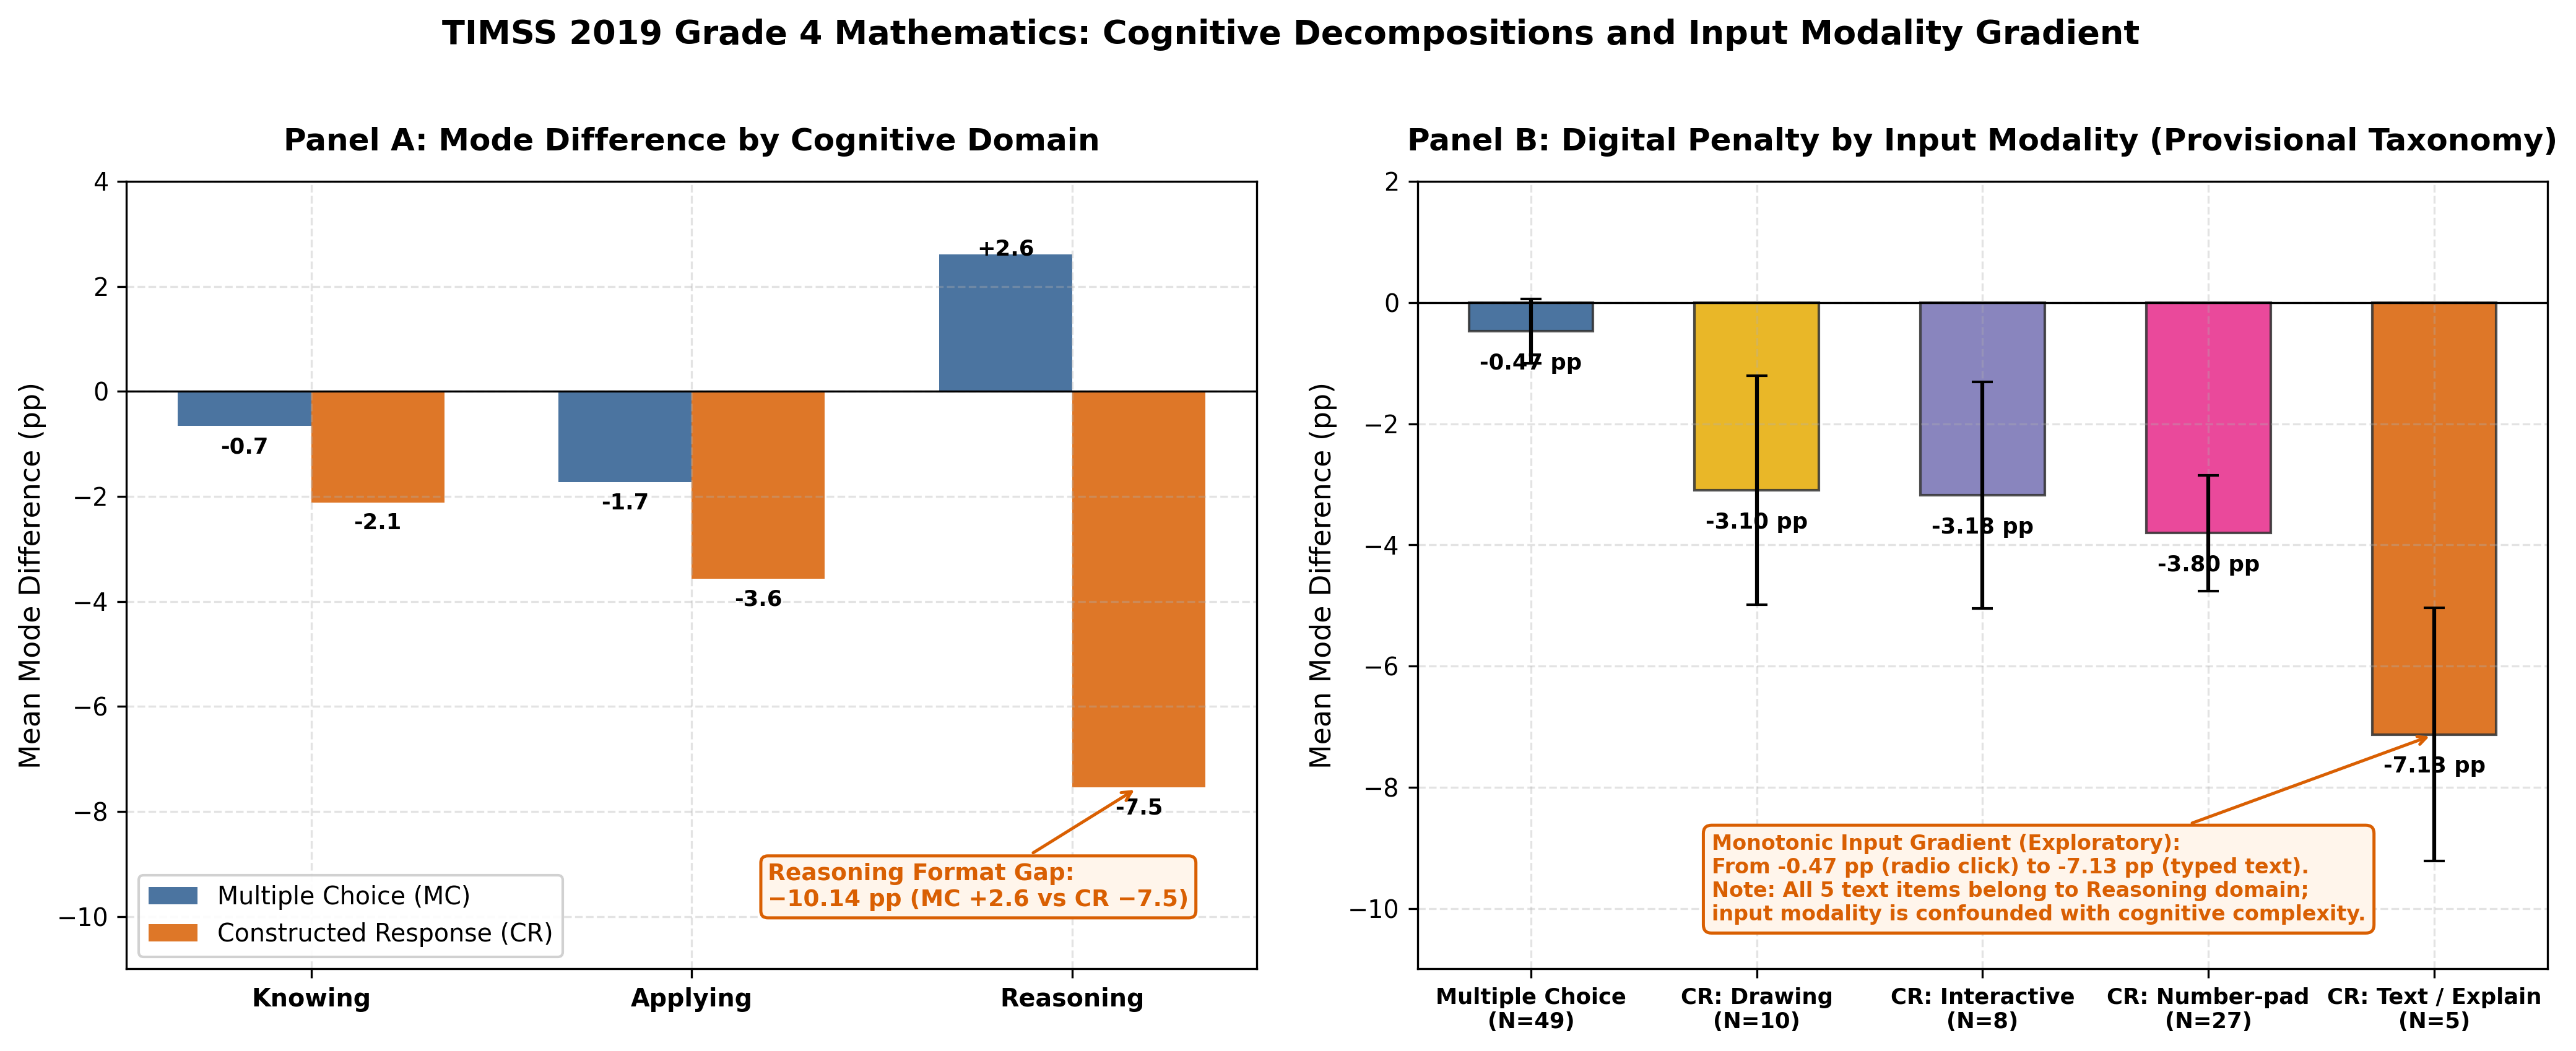

In [8]:
Image(filename=str(FIGURES_DIR / "fig6_timss_cognitive_content_domains.png"))


## 6. Socioeconomic Heterogeneity & Within-School Randomization

We test whether the digital format penalty compounds among students with fewer home resources or attending higher-poverty schools.

Table 8 reports scale scores and individual student format gaps ($CR\% - MC\%$) computed dynamically across subgroups.


In [9]:
df_sub = pd.read_csv(TABLES_DIR / "table8_timss_2019_subgroup_heterogeneity.csv")
display(df_sub)


,subgroup_dimension,subgroup_category,n_paper_students,n_digital_students,paper_pv_score,digital_pv_score,scale_diff_pts,paper_format_gap_pp,digital_format_gap_pp,format_mode_penalty_pp
0,Books in Home (SES Proxy),0–10 Books (None/Few),234,1418,478.7,488.3,9.5,-15.17,-19.59,-4.41
1,Books in Home (SES Proxy),11–25 Books (One shelf),353,2022,515.0,519.1,4.1,-14.61,-16.90,-2.29
2,Books in Home (SES Proxy),Low SES Combined (0–25 books),587,3440,500.5,506.4,5.8,-14.83,-18.01,-3.17
3,Books in Home (SES Proxy),26–100 Books (One bookcase),497,2532,557.5,551.1,-6.4,-11.33,-14.91,-3.58
4,Books in Home (SES Proxy),101–200 Books (Two bookcases),263,1109,576.7,568.5,-8.1,-12.40,-14.68,-2.28
5,Books in Home (SES Proxy),200+ Books (Three+ bookcases),207,1017,568.6,565.1,-3.5,-11.04,-13.88,-2.85
6,Books in Home (SES Proxy),High SES Combined (26+ books),967,4658,564.9,558.4,-6.5,-11.55,-14.63,-3.07
7,School Poverty (PCTFRPL),Less than 10% (Lowest Poverty),170,661,587.9,568.9,-19.0,-11.01,-13.18,-2.17
8,School Poverty (PCTFRPL),10% to 24.9%,239,1183,575.7,575.0,-0.6,-9.05,-14.13,-5.07
9,School Poverty (PCTFRPL),25% to 49.9%,333,1728,567.9,553.4,-14.5,-11.59,-15.63,-4.04


## 7. Econometric Estimation: Clustered Survey DiD, Item Fixed Effects, and Within-School Randomization

To account for TIMSS's complex sampling design, matrix-sampled booklet composition, clustering within schools, and within-school classroom assignment, we estimate five formal econometric models:

1. **Model 1 (National Survey-Weighted Student DiD)**: Full national sample ($N = 10,417$) with survey sampling weights (`TOTWGT`) clustered at the school level ($\beta = -3.102$ pp, $p < 0.0001$).
2. **Model 2 (National Item Fixed-Effects Panel WLS)**: Stacked student-by-item panel ($N = 164,653$ responses across 99 items and 294 schools) with 99 item baseline difficulty fixed effects ($\alpha_j$), fully controlling for booklet item composition ($\beta_2 = -3.422$ pp, $p = 3.0 \times 10^{-7}$).
3. **Model 3 (Within-School Student DiD)**: 72 schools with randomized classroom assignment ($N = 2,726$), controlling for school selection and neighborhood composition via school fixed effects ($\beta = -2.364$ pp, $p = 0.0065$).
4. **Model 4 (Within-School Item FE + School FE Panel)**: Stacked panel on 72 randomized schools ($N = 53,837$ responses) simultaneously absorbing 99 item fixed effects AND 72 school fixed effects, clustered by classroom ($\beta_2 = -2.734$ pp, $p = 0.00335$, 95% CI: $[-4.56, -0.91]$ pp).
5. **Model 5 (SES Interaction Test)**: Testing whether mode effects compound among lower-SES students ($\beta = -0.096$ pp, $p = 0.934$, 95% CI: $[-2.35, +2.16]$ pp).

Additionally, Table 11 reports survey-design uncertainty estimated via TIMSS Jackknife Repeated Replication (JK2 with 75 digital and 42 paper zones), yielding a design-based DiD standard error of $0.668$ pp ($t = -4.64, p < 0.00001$). Within the 72 schools, exact classroom randomization inference across 2,000 permutations confirms that the within-school penalty is statistically significant ($p = 0.0380$).


In [10]:
df_reg = pd.read_csv(TABLES_DIR / "table10_timss_2019_econometric_models.csv")
display(df_reg)

df_jk = pd.read_csv(TABLES_DIR / "table11_timss_2019_survey_inference_jk2.csv")
print("\n--- TIMSS Jackknife Repeated Replication (JK2 Design-Based Standard Errors) ---")
display(df_jk)


,model_specification,sample_scope,n_observations,coefficient_beta,cluster_robust_se,test_statistic,p_value,ci_95_lower,ci_95_upper,interpretation
0,Model 1: National Survey-Weighted Student DiD,Full National Sample (294 Schools),10417,-3.102,0.663,-4.68,0.000000e+00,-4.402,-1.802,National survey-weighted student format gap mo...
1,Model 2: National Item Fixed-Effects Panel WLS,"Full National Stacked Panel (99 Items, 294 Sch...",164653,-3.422,0.668,-5.12,3.000000e-07,-4.732,-2.112,Controls for matrix-sampling booklet item comp...
2,Model 3: Within-School Student DiD,72 Randomized-Classroom Schools (147 Classrooms),2726,-2.364,0.868,-2.72,6.460000e-03,-4.065,-0.663,Controls completely for school selection and n...
3,Model 4: Within-School Item FE + School FE Panel,"72 Randomized Schools Stacked Panel (99 Items,...",53837,-2.734,0.932,-2.93,3.350000e-03,-4.561,-0.907,Simultaneously absorbs 99 item baseline diffic...
4,Model 5: SES Interaction Term (Digital x Low SES),National Sample with SES Data (294 Schools),9648,-0.096,1.151,-0.08,9.336100e-01,-2.351,2.159,No detectable interaction (p=0.934); 95% CI [-...



--- TIMSS Jackknife Repeated Replication (JK2 Design-Based Standard Errors) ---


,parameter,paper_mean,paper_jk_se,digital_mean,digital_jk_se,mode_difference,jk2_standard_error,t_statistic,p_value,ci_95_lower,ci_95_upper
0,Student Format Gap DiD (CR% - MC%),-13.13,0.60,-16.23,0.30,-3.102,0.668,-4.64,0.00000,-4.412,-1.792
1,Multiple Choice Performance (MC%),63.00,1.06,62.27,0.64,-0.728,1.233,-0.59,0.55489,-3.144,1.688
2,Constructed Response Performance (CR%),49.87,1.37,46.04,0.71,-3.830,1.543,-2.48,0.01306,-6.854,-0.805


### Figure 7: Testing the Equity Gradient and Within-School Randomization
*Panel A shows that scale score differences are near-parallel across home book strata. Panel B shows that the constructed-response mode penalty is indistinguishable between Low SES (-3.17 pp) and High SES (-3.07 pp) with a null interaction (p=0.934, 95% CI [-2.35, +2.16] pp). Panel C displays the within-school randomized classroom contrast across the 72 schools with descriptive differences and rigorous fixed-effects models.*


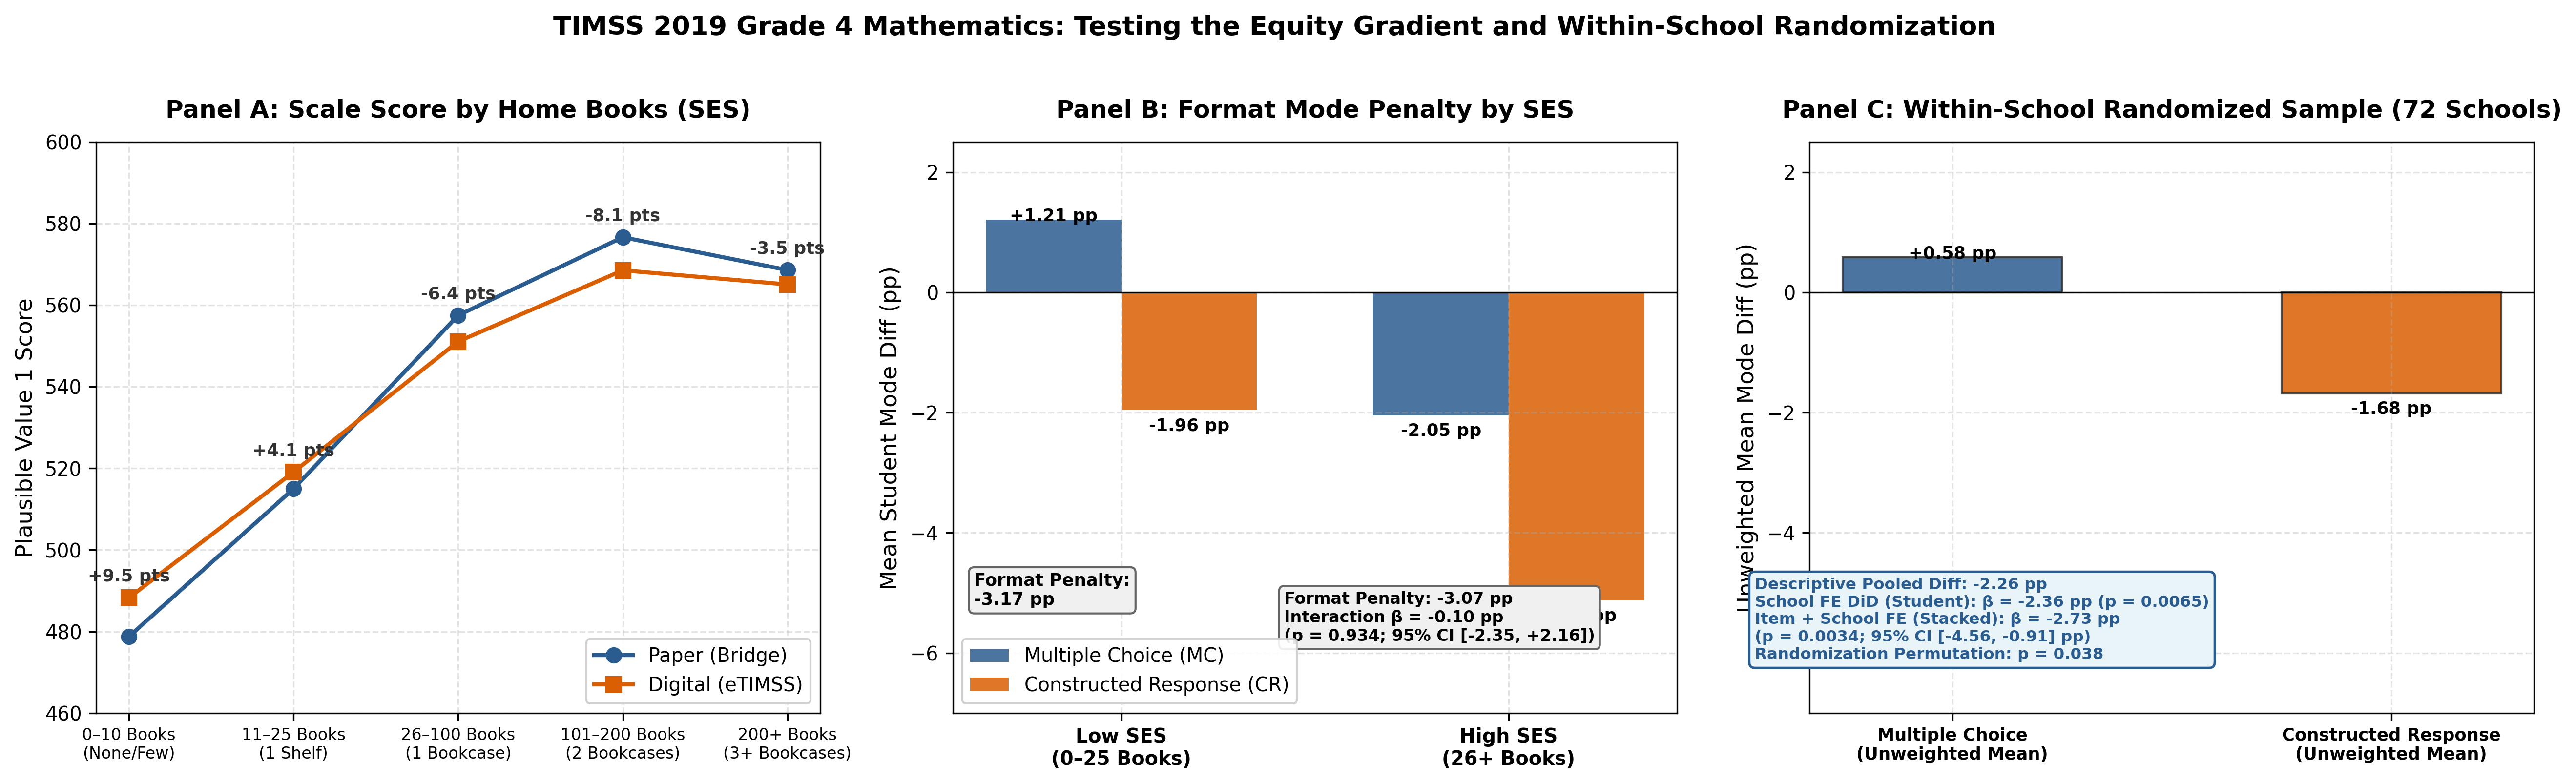

In [11]:
Image(filename=str(FIGURES_DIR / "fig7_timss_equity_and_counterarguments.png"))


## 8. Discussion & Synthesis: Answering the Three Research Questions

### Question 1: Does the digital assessment penalty differ by question format?
**Confirmed.** Across 99 common items, Multiple Choice items exhibit near-parity ($-0.47\text{ pp}$), while Constructed Response items suffer a statistically significant and substantial penalty ($-3.90\text{ pp}$), yielding a **$-3.42\text{ pp}$ format gap** ($t = -3.80$). Crucially, **booklet matrix sampling does not explain this gap**: in student-by-item regressions absorbing 99 item fixed effects, the interaction is **$-3.42\text{ pp}$** ($p < 0.00001$). Controlling for school fixed effects across 72 randomized schools, the penalty remains **$-2.36\text{ pp}$** ($p = 0.0065$). Absorbing both 99 item fixed effects and 72 school fixed effects simultaneously, the penalty is **$-2.73\text{ pp}$** ($p = 0.00335$ clustered by classroom; randomization permutation $p = 0.0380$).

### Question 2: Is the penalty driven by cognitive ability or interface friction?
**Interface Friction & Reasoning Confounding.** When fourth graders answer higher-order **Reasoning** items via multiple-choice radio buttons, their performance is $+2.61\text{ pp}$ higher on computer than on paper. But when answering Reasoning items requiring constructed explanations, their performance collapses by $-7.54\text{ pp}$, producing an acute **$-10.14\text{ pp}$ Reasoning wedge**. Across input modalities, the penalty appears monotonic: Multiple Choice ($-0.47$ pp) $\to$ Drawing ($-3.10$ pp) $\to$ Keypad ($-3.80$ pp) $\to$ Typed Text ($-7.13$ pp). However, because all 5 text items belong to the Reasoning domain, input modality is confounded with cognitive difficulty, and this taxonomy should be interpreted as provisional and exploratory.

### Question 3: Are penalties larger for low-SES or under-resourced students?
**No Detectable Moderation.** The mode penalty on constructed response is statistically indistinguishable across socioeconomic status: **$-3.17\text{ pp}$** for Low-SES students vs. **$-3.07\text{ pp}$** for High-SES students. The interaction coefficient in Model 5 is $\beta = -0.096\text{ pp}$ ($p = 0.934$). However, the 95% confidence interval ($[-2.35, +2.16]$ pp) does not rule out educationally meaningful heterogeneity up to $\pm 2.2$ pp. Rather than proving complete invariance, the empirical evidence demonstrates a lack of detectable moderation by home SES.
